In [1]:
from summarize_utils import SummarizePlotter
from urllib.parse import quote

def myquote(text):
    return quote(text)

original_path = "./datasets_parquet/wikimedia/wikipedia/20231101.ab.parquet"
compressed_path = "./datasets_compress/wikimedia/wikipedia/20231101.ab.parquet"

wiki_plotter = SummarizePlotter(original_path, compressed_path, "Datasets")
wiki_plotter.con.create_function('quote', myquote, [str], return_type=str)
wiki_plotter.add_target_column(
    "title",
    "SUBSTR(combine_title_text, 1, title_len)",
    "title_len"
)
wiki_plotter.add_target_column(
    "text",
    "SUBSTR(combine_title_text, title_len + 1)",
    "LENGTH(combine_title_text) - title_len"
)
wiki_plotter.add_target_column(
    "url",
    "'https://ab.wikipedia.org/wiki/' || quote(SUBSTR(combine_title_text, 1, title_len))",
    "30 + LENGTH(quote(SUBSTR(combine_title_text, 1, title_len)))"
)

Added target column: title
Added target column: text
Added target column: url


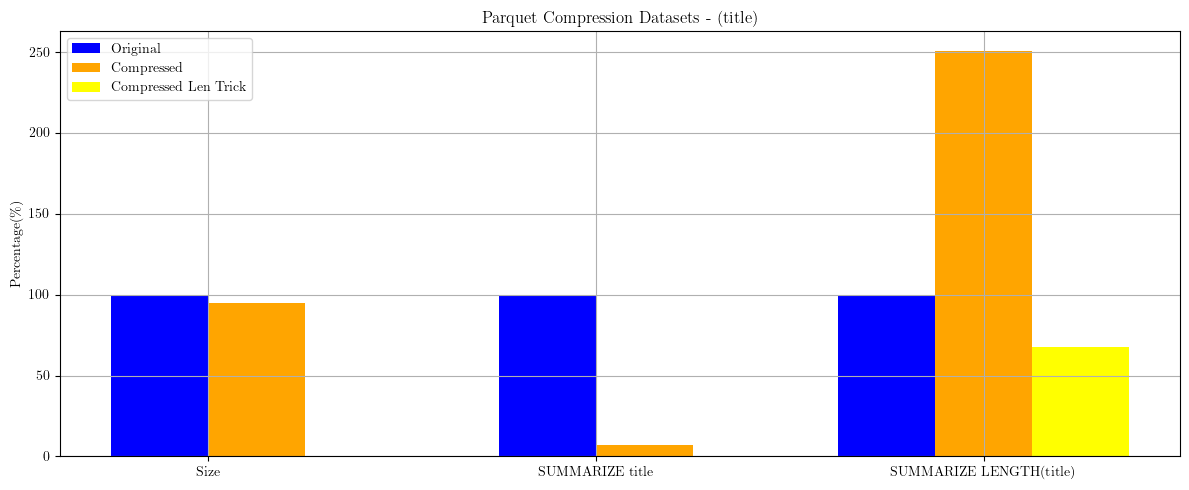

In [2]:
wiki_plotter.plot_target_column("title")

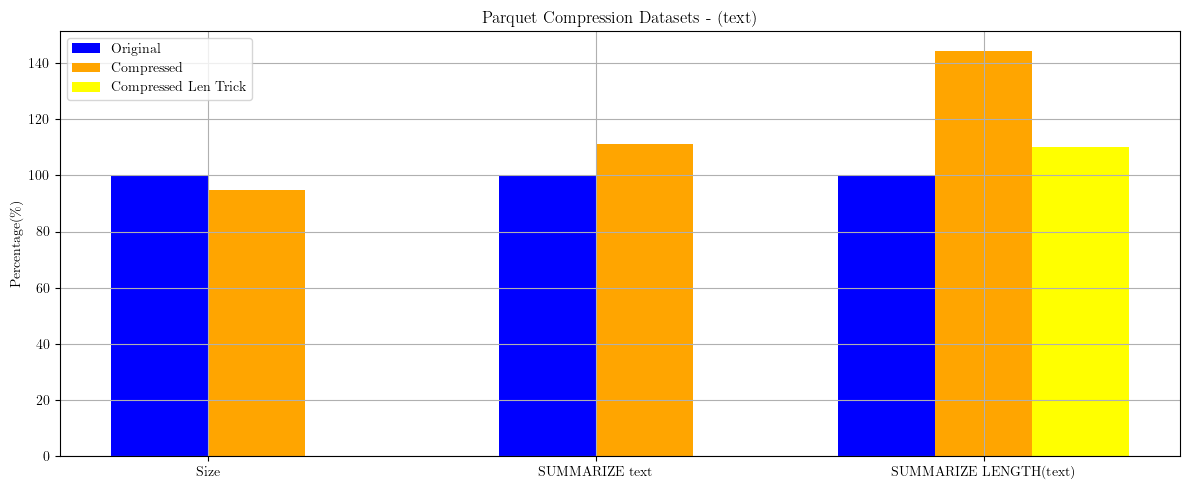

In [3]:
wiki_plotter.plot_target_column("text")

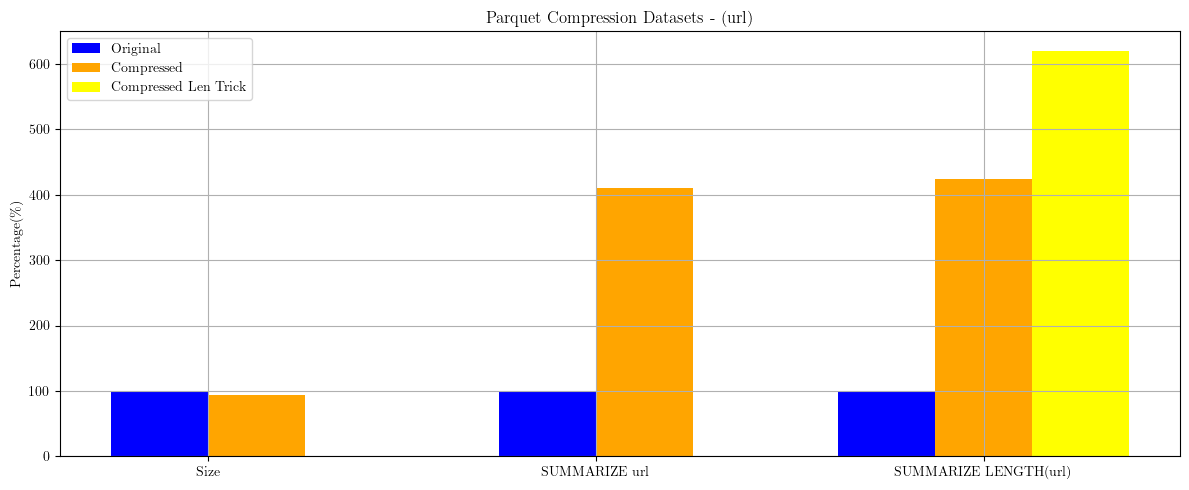

In [4]:
wiki_plotter.plot_target_column("url")

In [5]:
from urllib.parse import unquote

def strip_and_unquote(url, prefix):
    return unquote(url.replace(prefix, ""))

original_path = "./datasets_parquet/wikimedia/wikipedia/20231101.ab.parquet"
compressed_path = "./datasets_compress/wikimedia/wikipedia/20231101.ab-2.parquet"

wiki_plotter = SummarizePlotter(original_path, compressed_path, "Wiki Datasets")
wiki_plotter.con.create_function('strip_and_unquote', strip_and_unquote, [str, str], return_type=str)
wiki_plotter.add_target_column(
    "title",
    "strip_and_unquote(url, 'https://ab.wikipedia.org/wiki/')",
    "LENGTH(strip_and_unquote(url, 'https://ab.wikipedia.org/wiki/'))"
)


Added target column: title


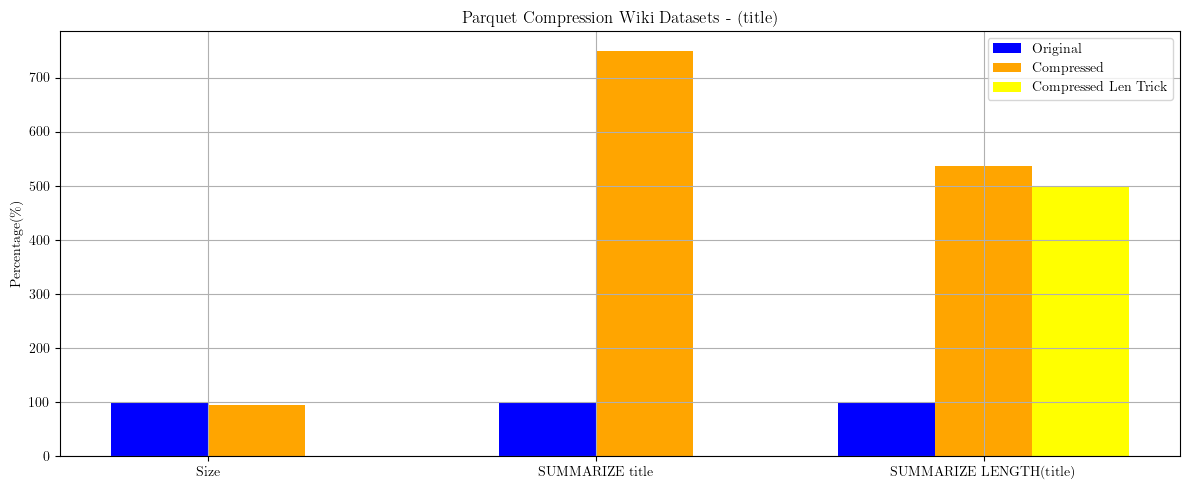

In [6]:
wiki_plotter.plot_target_column("title")